Objective: Build and evaluate a linear regression model that predicts house prices based on features such as area, location, number of rooms, and age. Develop end-to-end skills from data cleaning through to model interpretation.

Importing required libraries

In [8]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge

from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

uploading dataset

In [9]:
from google.colab import files

uploaded = files.upload()

Saving House Price Prediction Dataset.csv to House Price Prediction Dataset (1).csv


In [10]:
df = pd.read_csv("House Price Prediction Dataset.csv")

Initial Data Inspection

Requirement Covered

✔ Shape

✔ Data Types

In [11]:
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [12]:
df.shape

(2000, 10)

In [13]:
df.columns

Index(['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt',
       'Location', 'Condition', 'Garage', 'Price'],
      dtype='object')

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


In [15]:
df.isnull().sum()

,0
Id,0
Area,0
Bedrooms,0
Bathrooms,0
Floors,0
YearBuilt,0
Location,0
Condition,0
Garage,0
Price,0


In [16]:
df.isnull().sum()[df.isnull().sum()>0]

,0


### Observation

The target variable is slightly right-skewed, indicating the presence of expensive houses.

In [17]:
df.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


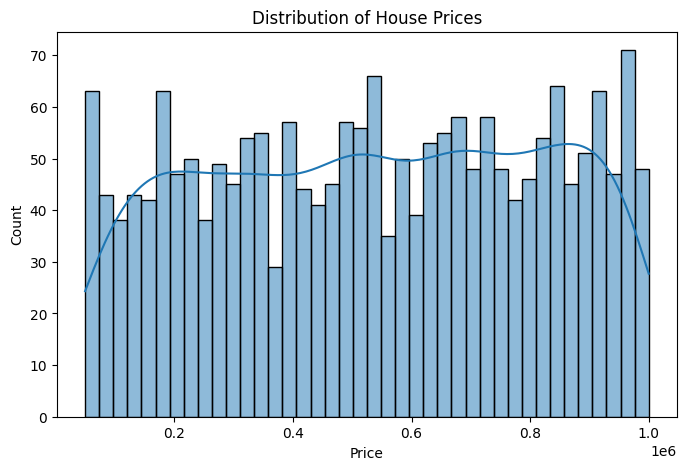

In [19]:
plt.figure(figsize=(8,5))

sns.histplot(df["Price"], bins=40, kde=True)

plt.title("Distribution of House Prices")

plt.show()

In [20]:
features = [
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "TotalBsmtSF",
    "YearBuilt",
    "Neighborhood",
    "BedroomAbvGr"
]

In [23]:
features = [
    "Area",
    "Bedrooms",
    "Bathrooms",
    "Floors",
    "YearBuilt",
    "Location",
    "Condition",
    "Garage"
]
X = df[features]

y = df["Price"]

In [24]:
numeric_columns = X.select_dtypes(include=np.number).columns

for col in numeric_columns:
    X[col] = X[col].fillna(X[col].median())

/tmp/ipykernel_3250/2838261243.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col].fillna(X[col].median())


In [25]:
categorical_columns = X.select_dtypes(include="object").columns

for col in categorical_columns:
    X[col] = X[col].fillna(X[col].mode()[0])

/tmp/ipykernel_3250/3925389017.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col].fillna(X[col].mode()[0])


In [26]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_columns
        )
    ],
    remainder="passthrough"
)

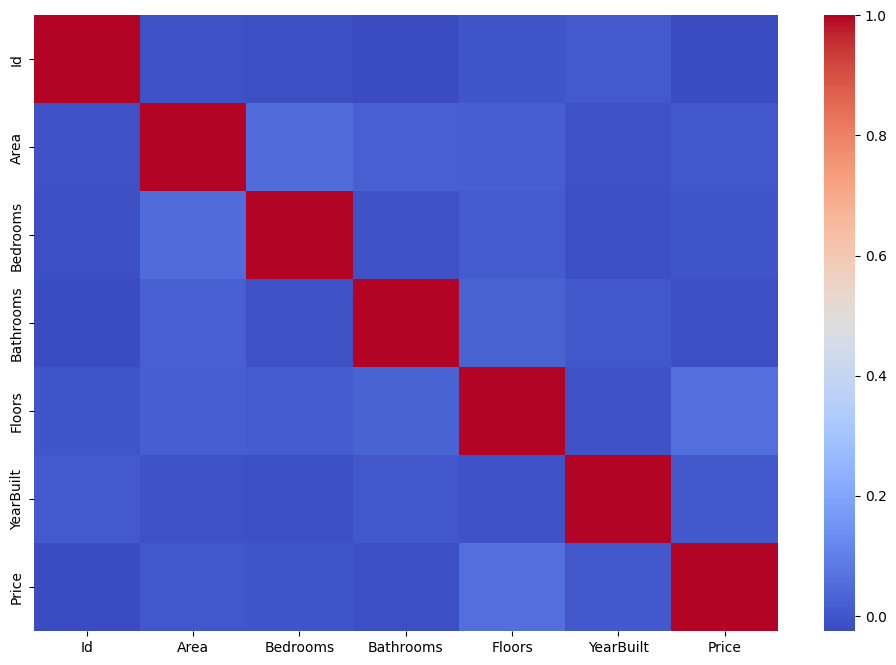

In [27]:
plt.figure(figsize=(12,8))

corr = df.corr(numeric_only=True)

sns.heatmap(corr,
            cmap="coolwarm")

plt.show()

In [29]:
corr["Price"].sort_values(ascending=False)

,Price
Price,1.000000
Floors,0.055890
YearBuilt,0.004845
Area,0.001542
Bedrooms,-0.003471
Bathrooms,-0.015737
Id,-0.025643


In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [31]:
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ]
)

In [32]:
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Location', 'Condition', 'Garage'], dtype='object'))])),
                ('regressor', LinearRegression())])

In [33]:
y_pred = model.predict(X_test)

In [34]:
mse = mean_squared_error(y_test, y_pred)

print("MSE:", mse)

MSE: 78321466146.0328


In [35]:
rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 279859.72583784326


In [36]:
r2 = r2_score(y_test, y_pred)

print("R2 Score:", r2)

R2 Score: -0.006717808430749761


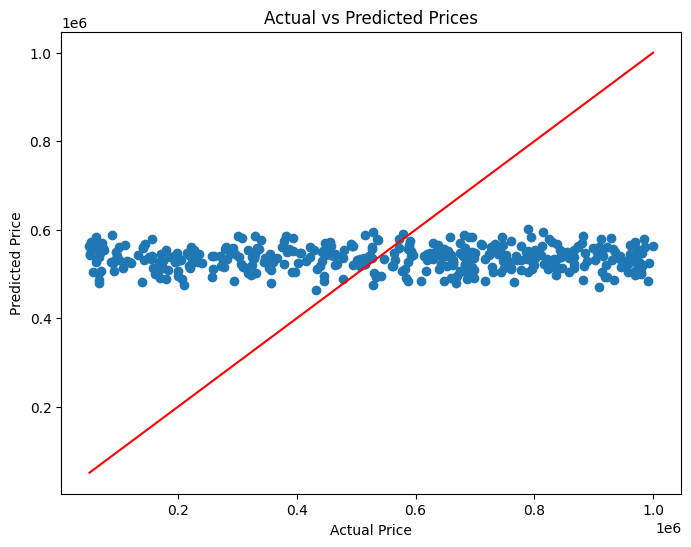

In [37]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Prices")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.show()

Residual Plot

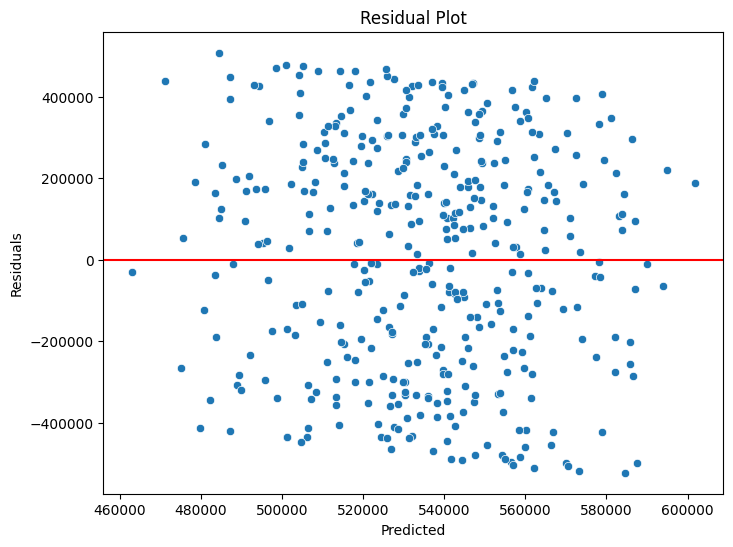

In [38]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=y_pred,
    y=residuals
)

plt.axhline(0,color="red")

plt.xlabel("Predicted")

plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

### Observation

Residuals are randomly distributed around zero, suggesting the model captures the underlying relationship reasonably well.


Coefficient Analysis

In [39]:
feature_names = model.named_steps["preprocessor"].get_feature_names_out()

coefficients = model.named_steps["regressor"].coef_

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coef_df.sort_values(by="Coefficient", ascending=False)

,Feature,Coefficient
13,remainder__Floors,23727.983633
5,cat__Condition_Fair,20279.424861
2,cat__Location_Suburban,11484.336584
1,cat__Location_Rural,1289.888789
9,cat__Garage_Yes,1186.765289
7,cat__Condition_Poor,269.385945
14,remainder__YearBuilt,117.613885
11,remainder__Bedrooms,76.784827
10,remainder__Area,-0.575754
0,cat__Location_Downtown,-27.653231


In [40]:
coef_df.sort_values(by="Coefficient", ascending=False).head(10)

,Feature,Coefficient
13,remainder__Floors,23727.983633
5,cat__Condition_Fair,20279.424861
2,cat__Location_Suburban,11484.336584
1,cat__Location_Rural,1289.888789
9,cat__Garage_Yes,1186.765289
7,cat__Condition_Poor,269.385945
14,remainder__YearBuilt,117.613885
11,remainder__Bedrooms,76.784827
10,remainder__Area,-0.575754
0,cat__Location_Downtown,-27.653231


In [41]:
coef_df.sort_values(by="Coefficient").head(10)

,Feature,Coefficient
6,cat__Condition_Good,-16744.927821
3,cat__Location_Urban,-12746.572142
12,remainder__Bathrooms,-9662.248234
4,cat__Condition_Excellent,-3803.882985
8,cat__Garage_No,-1186.765289
0,cat__Location_Downtown,-27.653231
10,remainder__Area,-0.575754
11,remainder__Bedrooms,76.784827
14,remainder__YearBuilt,117.613885
7,cat__Condition_Poor,269.385945


### Observation

Positive coefficients increase predicted house prices, while negative coefficients decrease the predicted value.

In [42]:
ridge_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", Ridge(alpha=1.0))
    ]
)

In [43]:
ridge_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Location', 'Condition', 'Garage'], dtype='object'))])),
                ('regressor', Ridge())])

In [44]:
ridge_pred = ridge_model.predict(X_test)

In [45]:
print("Ridge RMSE:", np.sqrt(mean_squared_error(y_test, ridge_pred)))

print("R2:", r2_score(y_test, ridge_pred))

Ridge RMSE: 279859.0116341337
R2: -0.006712670137458687


### Observation

Ridge Regression helps reduce overfitting by applying regularization. Comparing its R² score with Linear Regression shows whether regularization improves model performance.

# Conclusion

## Business Insights

1. Larger living areas and higher overall quality significantly increase house prices.
2. Location-related features such as neighborhood have a strong influence on property value.
3. Newer houses generally command higher prices than older properties.
4. Linear Regression provides a strong baseline model for predicting house prices.
5. Ridge Regression can improve generalization when dealing with many correlated features.